In [1]:

import pandas as pd
import numpy as np
import duckdb
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [5]:
df_1 = pd.read_csv('/content/drive/MyDrive/FIAP/Tech Challenge 4/Obesity.csv')

In [6]:
df_1.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
df_1.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [8]:
# Retirando altura e peso do modelo para não ocorrer overfitting
df_1 = df_1.drop(columns=['Height', 'Weight'], errors='ignore')

map_binario = {'yes': 1, 'no': 0, 'Male': 1, 'Female': 0}
for col in ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']:
    df_1[col] = df_1[col].map(map_binario)


# Transformar em dummies
df_1 = pd.get_dummies(df_1, columns=['CAEC', 'CALC', 'MTRANS'])


# score de atividade física (FAF alto e TUE baixo = mais ativo)
df_1['exercicio_score'] = df_1['FAF'] * (2 - df_1['TUE'])

# índice de sedentarismo (TUE alto e FAF baixo = mais sedentário)
df_1['sedentarismo'] = df_1['TUE'] * (3 - df_1['FAF'])


obesidade_ordenado = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

target_map = {label: idx for idx, label in enumerate(obesidade_ordenado)}
df_1['Obesity_encoded'] = df_1['Obesity'].map(target_map)

In [9]:
df_1.head()

,Gender,Age,family_history,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,...,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,exercicio_score,sedentarismo,Obesity_encoded
0,0,21.0,1,0,2.0,3.0,0,2.0,0,0.0,...,False,True,False,False,False,True,False,0.0,3.0,1
1,0,21.0,1,0,3.0,3.0,1,3.0,1,3.0,...,True,False,False,False,False,True,False,6.0,0.0,1
2,1,23.0,1,0,2.0,3.0,0,2.0,0,2.0,...,False,False,False,False,False,True,False,2.0,1.0,1
3,1,27.0,0,0,3.0,3.0,0,2.0,0,2.0,...,False,False,False,False,False,False,True,4.0,0.0,2
4,1,22.0,0,0,2.0,1.0,0,2.0,0,0.0,...,True,False,False,False,False,True,False,0.0,0.0,3


In [10]:
df_1.describe()

,Gender,Age,family_history,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,exercicio_score,sedentarismo,Obesity_encoded
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,0.505921,24.312600,0.817622,0.883941,2.419043,2.685628,0.020843,2.008011,0.045476,1.010298,0.657866,1.325637,1.278640,3.112269
std,0.500083,6.345968,0.386247,0.320371,0.533927,0.778039,0.142893,0.612953,0.208395,0.850592,0.608927,1.348344,1.429426,1.985062
min,0.000000,14.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,19.947192,1.000000,1.000000,2.000000,2.658738,0.000000,1.584812,0.000000,0.124505,0.000000,0.024729,0.000000,1.000000
50%,1.000000,22.777890,1.000000,1.000000,2.385502,3.000000,0.000000,2.000000,0.000000,1.000000,0.625350,1.000000,0.967998,3.000000
75%,1.000000,26.000000,1.000000,1.000000,3.000000,3.000000,0.000000,2.477420,0.000000,1.666678,1.000000,2.000000,2.000000,5.000000
max,1.000000,61.000000,1.000000,1.000000,3.000000,4.000000,1.000000,3.000000,1.000000,3.000000,2.000000,6.000000,6.000000,6.000000


<Axes: >

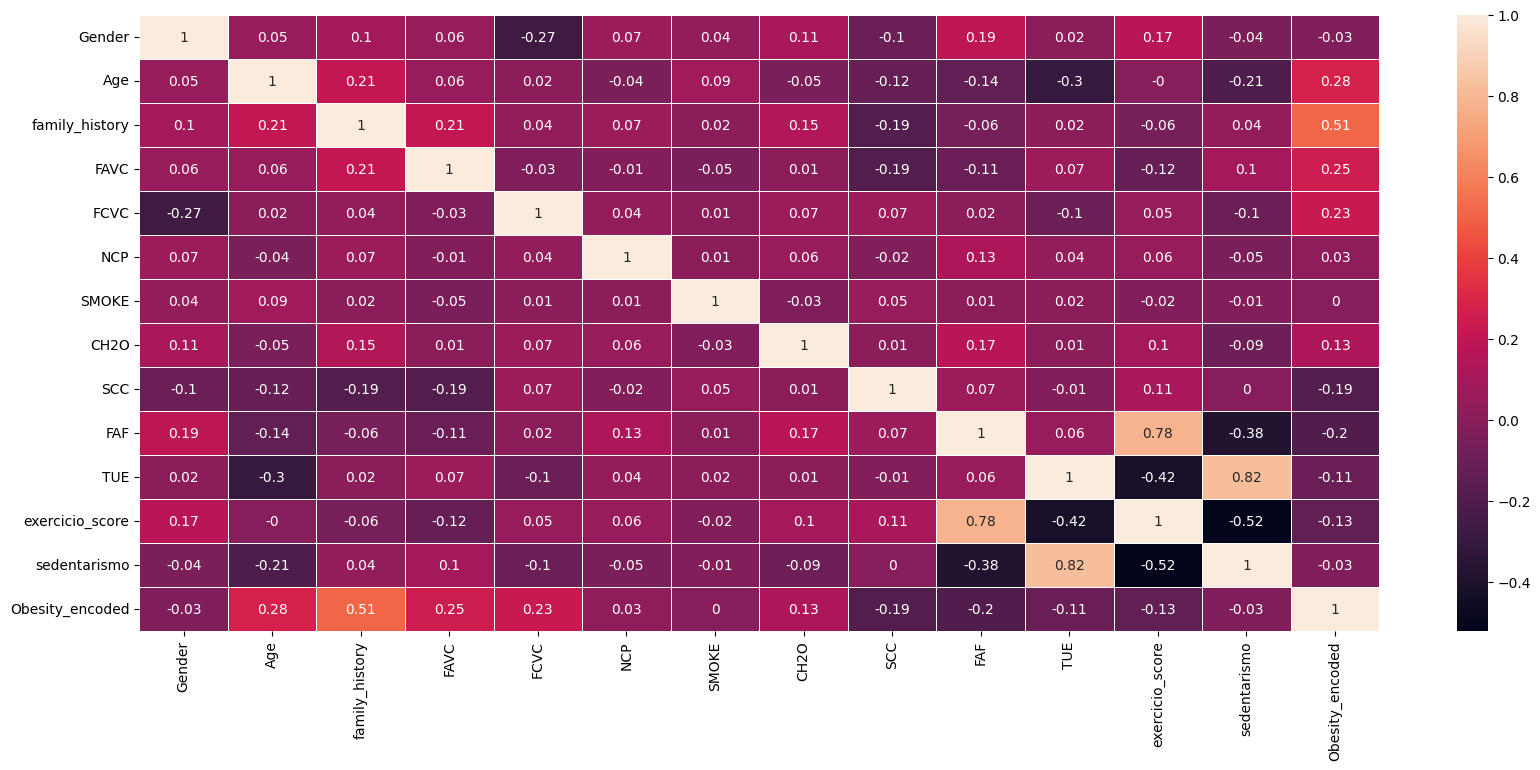

In [11]:
matriz_correlacao = df_1.select_dtypes(include='number').corr().round(2)

fig, ax = plt.subplots(figsize=(20,8))
sns.heatmap(data=matriz_correlacao, annot=True, linewidths=.5, ax=ax)

In [13]:
# Definir features e target
colunas_modelo = [c for c in df_1.columns if c not in ['Obesity', 'Obesity_encoded']]

X = df_1[colunas_modelo]
y = df_1['Obesity_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')
print(f'Features: {X_train.shape[1]}')

Treino: 1688 amostras
Teste:  423 amostras
Features: 26


In [17]:
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'{name:25s} → Acurácia: {scores.mean():.4f}')

Random Forest             → Acurácia: 0.8489
Gradient Boosting         → Acurácia: 0.8051


In [18]:
from sklearn.preprocessing import StandardScaler

# Normalizar os dados
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Treinar
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_sc, y_train)


acc_teste  = accuracy_score(y_test,  lr.predict(X_test_sc))

print(f'Acurácia:  {acc_teste:.4f}')

Acurácia:  0.6241


In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

acc_teste  = accuracy_score(y_test,  xgb.predict(X_test))

print(f'Acurácia: {acc_teste:.4f}')

Acurácia: 0.8298


In [20]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

acc_teste  = accuracy_score(y_test,  best_model.predict(X_test))

print(f'Acurácia {acc_teste:.4f}')

Acurácia 0.8416


In [21]:
# Modelo escolhido: Random Forest (melhor resultado com 85% de acurácia)
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

acc_teste  = accuracy_score(y_test,  best_model.predict(X_test))

print(f'Acurácia: {acc_teste:.4f}')

Acurácia: 0.8416


In [ ]:
import joblib

joblib.dump(best_model, 'model.pkl')

joblib.dump(colunas_modelo, 'feature_columns.pkl')

target_decoder = {v: k for k, v in target_map.items()}
joblib.dump(target_decoder, 'target_decoder.pkl')

from google.colab import files
files.download('model.pkl')
files.download('feature_columns.pkl')
files.download('target_decoder.pkl')